# This is just for fun


# Ran correctly 25-05-2026 in the morning.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv(r"C:/Users\ulrik\OneDrive - University of Copenhagen\År4\Applied Machine Learning\final_project\git_hub_final_project\scrandle_ml_project\data\grand_scraper_folder\unique_scrandle_cases_FULL.csv")

#df.head()

beer_df = df[
    df["title"].str.contains("beer", case=False, na=False) |
    df["subtitle"].str.contains("beer", case=False, na=False)
] #Whilke har oel?

# Convert country column into list (important!)
df["country_list"] = df["country"].fillna("").apply(lambda x: x.split(" | "))


In [6]:
titles = df["title"].tolist()
subtitles = df["subtitle"].tolist()
prices = df["price"].tolist()
ratings = df["rating"].tolist()
hashes = df["image_hash"].tolist()
occurrences = df["occurrences"].tolist()


In [7]:
# Count occurrences per row
df["n_appear"] = df["occurrences"].apply(lambda x: len(x.split(" | ")))
print(df["n_appear"])

0       7
1       1
2       6
3       4
4       5
       ..
4583    1
4584    1
4585    1
4586    1
4587    1
Name: n_appear, Length: 4588, dtype: int64


In [8]:
n_beer = len(beer_df)
n_total = len(df)

print(f"Beer cases: {n_beer}")
print(f"Total cases: {n_total}")


mean_beer = beer_df["rating"].mean()
mean_all = df["rating"].mean()

print(f"Average rating (beer): {mean_beer:.2f}")
print(f"Average rating (all):  {mean_all:.2f}")

Beer cases: 102
Total cases: 4588
Average rating (beer): 53.74
Average rating (all):  52.85


In [9]:
std_beer = beer_df["rating"].std()
std_all = df["rating"].std()

print(f"Std (beer): {std_beer:.2f}")
print(f"Std (all):  {std_all:.2f}")


Std (beer): 23.73
Std (all):  26.09


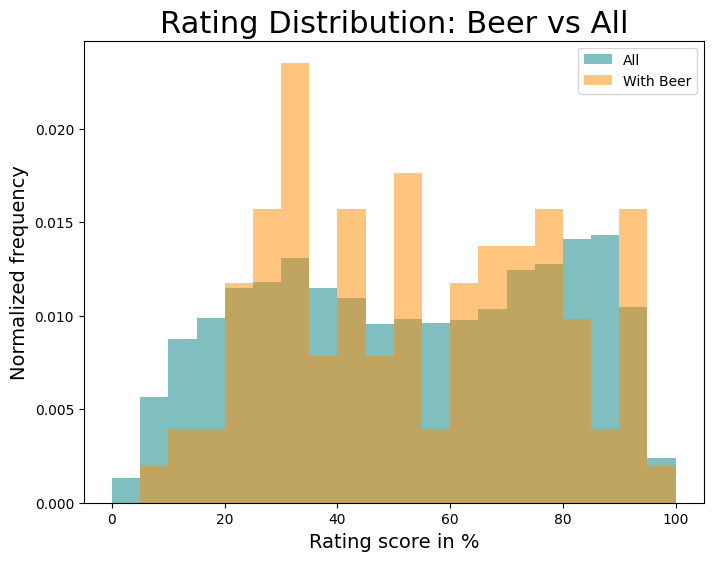

In [10]:
bins = np.arange(0, 105, 5)



plt.figure(figsize = (8,6))
plt.hist(df["rating"], bins=bins, alpha=0.5, label="All", density = True, color = "teal")
plt.hist(beer_df["rating"], bins=bins, alpha=0.5, label="With Beer" , density  = True, color = "darkorange")

plt.legend()
plt.xlabel("Rating score in %", fontsize = 14 )
plt.ylabel("Normalized frequency", fontsize = 14)
plt.title("Rating Distribution: Beer vs All", fontsize = 22)
plt.show()


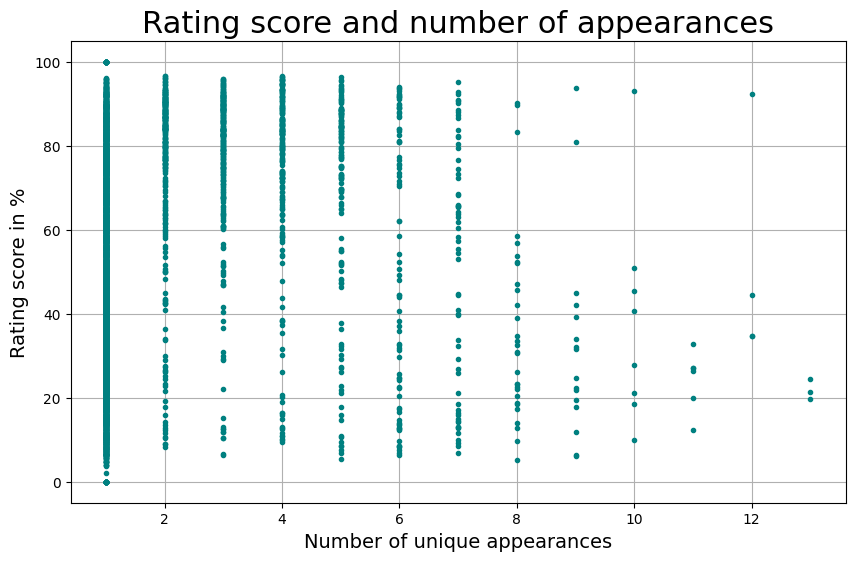

In [11]:
plt.figure(figsize = (10,6))

plt.plot(df["n_appear"], df["rating"], '.',color = 'teal')

plt.xlabel('Number of unique appearances', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and number of appearances', fontsize = 22)
plt.grid()
plt.show()





In [12]:
mask = df["price"].notna()
print(mask)

Jakobs_rate = df['rating'][mask]
Jakobs_price = df['price'][mask]
Jakobs_price

0       True
1       True
2       True
3       True
4       True
        ... 
4583    True
4584    True
4585    True
4586    True
4587    True
Name: price, Length: 4588, dtype: bool


0        2.60
1        9.50
2        2.80
3        3.40
4        5.50
        ...  
4583     5.20
4584     3.40
4585     5.50
4586    16.45
4587     7.95
Name: price, Length: 4250, dtype: float64

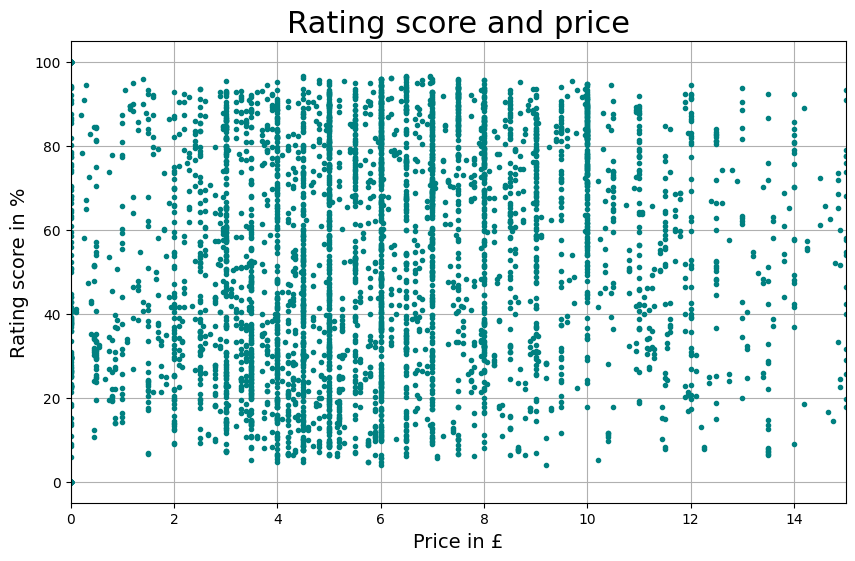

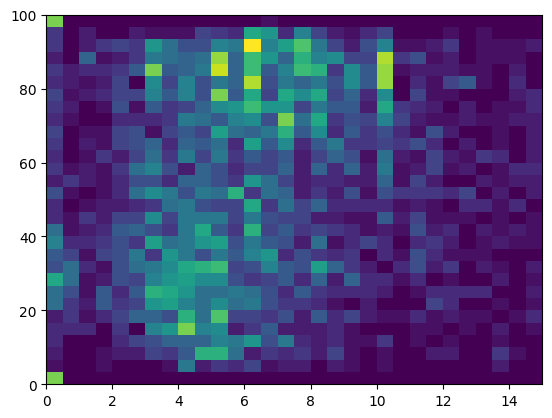

In [13]:
plt.figure(figsize = (10,6))

plt.plot( df["price"], df["rating"], '.',color = 'teal')

plt.xlabel('Price in £', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and price', fontsize = 22)
plt.grid()
plt.xlim([0,15])
plt.show()

plt.hist2d(Jakobs_price, Jakobs_rate, bins  =30, range  = [[0,15],[0,100]])
plt.xlim([0,15])
plt.show()

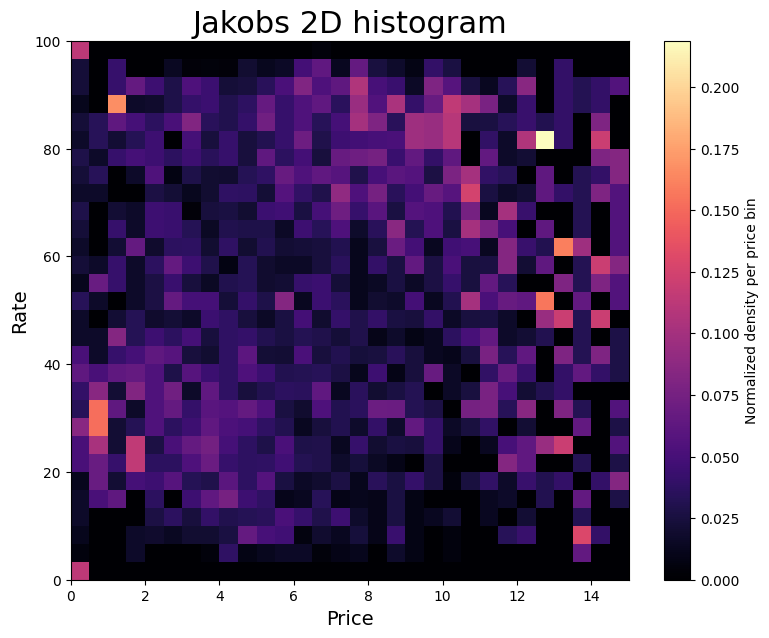

In [14]:
# Compute 2D histogram
H, xedges, yedges = np.histogram2d(
    Jakobs_price, Jakobs_rate,
    bins=30,
    range=[[0, 15], [0, 100]]
)

# Normalize each column (along y-axis)
H_norm = H / H.sum(axis=1, keepdims=True)  # normalize per price bin

# Avoid division by zero
H_norm = np.nan_to_num(H_norm)

# Plot
plt.figure(figsize = (9,7))
plt.pcolormesh(xedges, yedges, H_norm.T, shading='auto', cmap = 'magma')
plt.colorbar(label='Normalized density per price bin')
plt.title('Jakobs 2D histogram', fontsize = 22)
plt.xlabel('Price', fontsize = 14)
plt.ylabel('Rate', fontsize = 14)
plt.show()

# Herefrom follows country analyses.

In [15]:
# Explode countries into separate rows
df_country = df.explode("country_list")

# Remove empty ones
df_country = df_country[df_country["country_list"] != ""]

# Group stats
country_stats = df_country.groupby("country_list")["rating"].agg(["mean", "std", "count"])

# Optional: filter only countries with enough data
country_stats = country_stats[country_stats["count"] >= 5]

# Sort
country_stats = country_stats.sort_values("mean", ascending=False)

print(country_stats.head())

                   mean        std  count
country_list                             
KOR           81.595882  14.500521     17
COL           70.650000  17.962016      7
BEL           65.465385  25.375295     13
THA           64.092000  27.877843     15
SWE           63.300000  22.240879     12


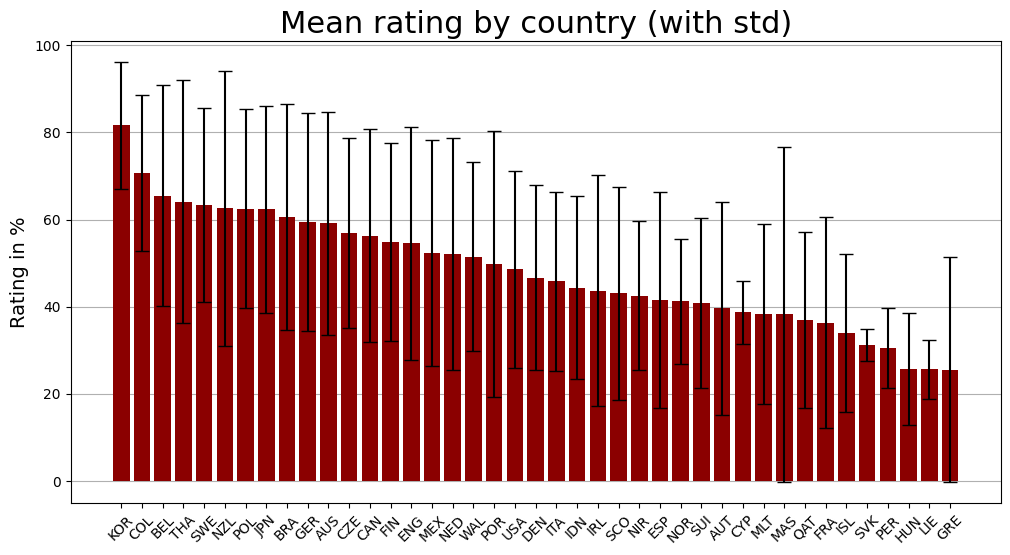

In [28]:
plt.figure(figsize=(12,6))

plt.bar(country_stats.index, country_stats["mean"], yerr=country_stats["std"], color = 'darkred', capsize=5, zorder = 3)

plt.xticks(rotation=45)
plt.ylabel("Rating in %", fontsize = 14)
plt.title("Mean rating by country (with std)", fontsize = 22)
plt.grid(axis='y')

plt.show()


# Compare types of foods.

In [50]:
keywords = {
    "burger": r"burger",           # includes cheeseburger etc.
    "hotdog": r"\bhot\s*dog\b",   # hotdog + hot dog
    "sandwich": r"sandwich",
    "pie": r"pie",
    "sausage": r"sausage",
    "chees": r"cheese",
    "mash": r"mash",
    "doughnut": r"donut",
    "poutine": r"poutine",
    "fries": r"fries",
    "soda": r"soda",
    "beer": r"beer"
}


def keyword_stats_regex(df, keywords):
    results = {}

    for name, pattern in keywords.items():
        mask = (
            df["title"].str.contains(pattern, case=False, na=False, regex=True) |
            df["subtitle"].str.contains(pattern, case=False, na=False, regex=True)
        )

        subset = df[mask]

        results[name] = {
            "mean": subset["rating"].mean(),
            "std": subset["rating"].std(),
            "count": len(subset)
        }

    return pd.DataFrame(results).T

kw_stats = keyword_stats_regex(df, keywords)


In [51]:
kw_stats = keyword_stats_regex(df, keywords)

print(kw_stats)

               mean        std  count
burger    52.477932  29.555256  556.0
hotdog    36.835882  23.258546  374.0
sandwich  47.289315  24.771989  146.0
pie       41.559209  21.215048  468.0
sausage   54.051136  23.982596  361.0
chees     52.993980  27.305758  613.0
mash      50.314823  24.793685  141.0
doughnut  63.404167  21.055328   12.0
poutine   69.703810  19.597890   21.0
fries     71.385869  19.642793  351.0
soda      43.307143   9.820554    7.0
beer      53.743333  23.730510  102.0


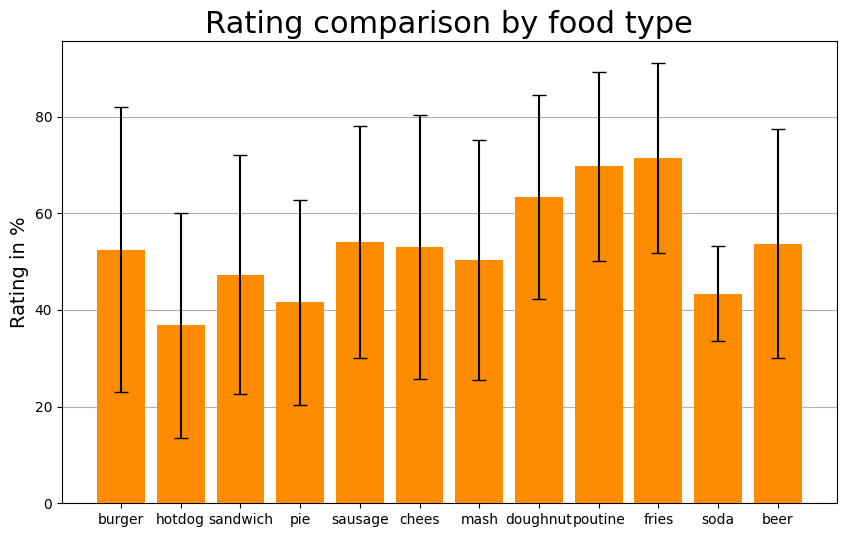

In [52]:
plt.figure(figsize=(10,6))

plt.bar(kw_stats.index, kw_stats["mean"], yerr=kw_stats["std"], color = "darkorange", capsize=5, zorder = 3)

plt.ylabel("Rating in %", fontsize = 14)
plt.title("Rating comparison by food type", fontsize = 22)
plt.grid(axis='y')

plt.show()


In [ ]:
# Tryn restnet later.

